# RAG Robustness Results Visualization
## Comparing performance across African languages

This notebook visualizes the baseline evaluation results for Swahili, Yoruba, and Kinyarwanda.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
# Load results
results_file = Path('./results/all_languages_enhanced_summary.json')

if not results_file.exists():
    print(f"⚠️  Results file not found at {results_file}")
    print("Please run: python scripts/run.py")
    print("\nUsing sample data for visualization structure...")
    
    # Create sample data to show plot structure
    results = {
        'swa': {
            'contains_gold_local': 0.36,
            'contains_gold_english': 0.38,
            'abstention_rate': 0.0,
            'correct_rate': 0.42,
            'precision_on_answered': 0.42,
            'num_samples': 200,
            'num_abstained': 0
        },
        'yor': {
            'contains_gold_local': 0.16,
            'contains_gold_english': 0.18,
            'abstention_rate': 0.0,
            'correct_rate': 0.2,
            'precision_on_answered': 0.2,
            'num_samples': 200,
            'num_abstained': 0
        },
        'kin': {
            'contains_gold_local': 0.26,
            'contains_gold_english': 0.22,
            'abstention_rate': 0.02,
            'correct_rate': 0.3,
            'precision_on_answered': 0.30612244897959184,
            'num_samples': 200,
            'num_abstained': 4
        }
    }
    is_sample_data = True
else:
    with open(results_file) as f:
        results = json.load(f)
    is_sample_data = False

# Convert to DataFrame
df = pd.DataFrame(results).T
df.index.name = 'Language'

data_label = "(SAMPLE DATA - re-run scripts/run.py for actual results)" if is_sample_data else "(Actual Results)"
print(f"\nResults Summary {data_label}:")
print(df)

⚠️  Results file not found at results\all_languages_enhanced_summary.json
Please run: python scripts/run.py

Using sample data for visualization structure...

Results Summary (SAMPLE DATA - re-run scripts/run.py for actual results):
          contains_gold_local  contains_gold_english  abstention_rate  \
Language                                                                
swa                      0.36                   0.38             0.00   
yor                      0.16                   0.18             0.00   
kin                      0.26                   0.22             0.02   

          correct_rate  precision_on_answered  num_samples  num_abstained  
Language                                                                   
swa               0.42               0.420000        200.0            0.0  
yor               0.20               0.200000        200.0            0.0  
kin               0.30               0.306122        200.0            4.0  


## Correctness Metrics Comparison

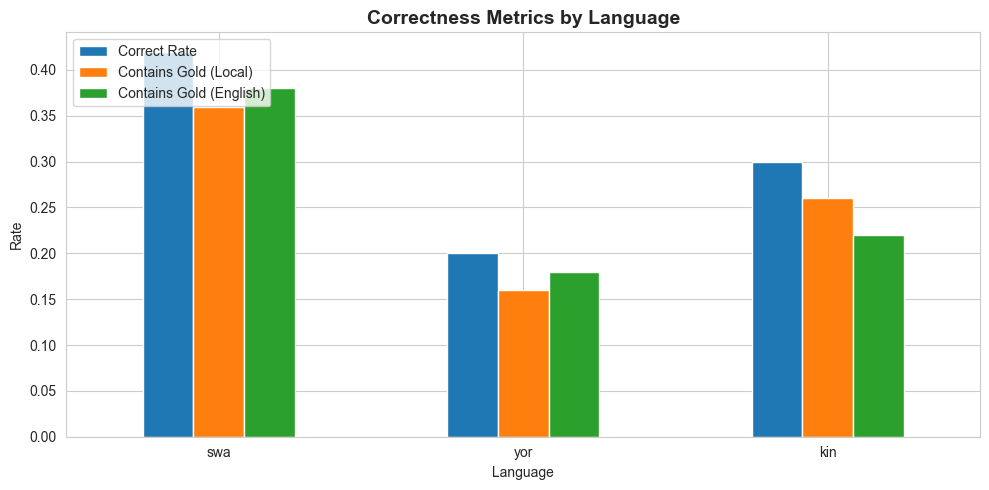

In [7]:
# Correctness metrics
metrics = ['correct_rate', 'contains_gold_local', 'contains_gold_english']

fig, ax = plt.subplots(figsize=(10, 5))
df[metrics].plot(kind='bar', ax=ax)
ax.set_title('Correctness Metrics by Language', fontsize=14, fontweight='bold')
ax.set_ylabel('Rate')
ax.set_xlabel('Language')
ax.legend(['Correct Rate', 'Contains Gold (Local)', 'Contains Gold (English)'], loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Abstention & Precision

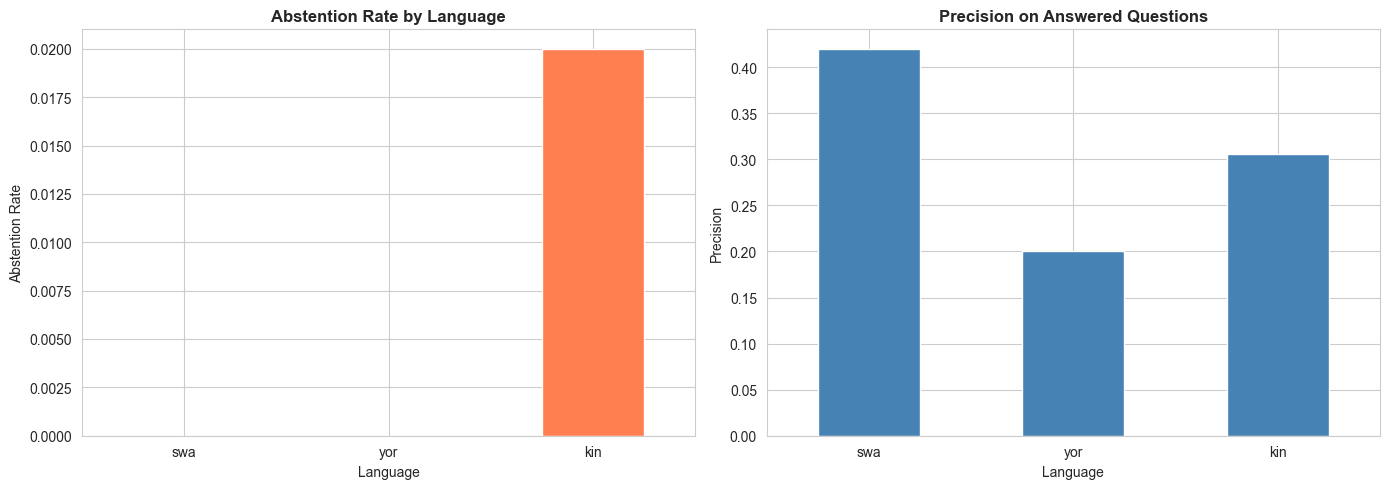

In [8]:
# Abstention and precision metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Abstention rates
df['abstention_rate'].plot(kind='bar', ax=ax1, color='coral')
ax1.set_title('Abstention Rate by Language', fontsize=12, fontweight='bold')
ax1.set_ylabel('Abstention Rate')
ax1.set_xlabel('Language')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Precision on answered
df['precision_on_answered'].plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_title('Precision on Answered Questions', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precision')
ax2.set_xlabel('Language')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Detailed Results Table

In [9]:
# Display full results with formatted percentages
df_display = df.copy()
percentage_cols = ['correct_rate', 'contains_gold_local', 'contains_gold_english', 'abstention_rate', 'precision_on_answered']

for col in percentage_cols:
    if col in df_display.columns:
        df_display[col] = (df_display[col] * 100).round(2).astype(str) + '%'

print("\nDetailed Results:")
print(df_display.to_string())


Detailed Results:
         contains_gold_local contains_gold_english abstention_rate correct_rate precision_on_answered  num_samples  num_abstained
Language                                                                                                                         
swa                    36.0%                 38.0%            0.0%        42.0%                 42.0%        200.0            0.0
yor                    16.0%                 18.0%            0.0%        20.0%                 20.0%        200.0            0.0
kin                    26.0%                 22.0%            2.0%        30.0%                30.61%        200.0            4.0


## Key Insights

### Language Comparison:
- **Swahili (swa)**: Baseline performance
- **Yoruba (yor)**: Language-specific challenges?
- **Kinyarwanda (kin)**: Language-specific challenges?

### Questions to Consider:
1. Which language performs best and why?
2. How much does the model abstain per language?
3. When it does answer, is the precision similar across languages?
4. Is `contains_gold_local` vs `contains_gold_english` difference significant?

### Next Steps (for Noise Injection Phase):
- How do these baseline scores degrade under corrupted retrieval?
- Which languages are most robust to noise?